# Fase 2 - Modelos ML: TF-IDF y GloVe
Implementación y evaluación de LR, RF y SVM con dos representaciones textuales:
TF-IDF de palabras y GloVe SBWC en español. Se evalúa sobre el corpus combinado
(3 variantes) y por variante individual. GridSearchCV con Stratified K-Fold (5 folds)
optimizando F1-Macro (Bhattacharjee et al., 2023; Ortega-Bueno et al., 2022).

## 1. Importación de librerías

In [16]:
import pandas as pd
import numpy as np
import gzip, shutil, os, time
import joblib

import nltk
from nltk.corpus import stopwords
nltk.download('stopwords', quiet=True)

from gensim.scripts.glove2word2vec import glove2word2vec
from gensim.models import KeyedVectors

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    f1_score, accuracy_score,
    precision_score, recall_score, classification_report
)

## 2. Configuración de rutas y constantes

In [17]:
# ── Rutas (relativas a la carpeta notebooks/) ────────────────────────────────
DATA_DIR   = '../data'
MODELS_DIR = '../data/modelos'
GLOVE_GZ   = '../glove-sbwc.i25.vec.gz'
GLOVE_VEC  = '../glove-sbwc.i25.vec'
GLOVE_W2V  = '../glove-sbwc-w2v.vec'

os.makedirs(MODELS_DIR, exist_ok=True)

# ── Features lingüísticos (9 variables) ─────────────────────────────────────
FEATURE_COLS = ['n_exc','n_int','n_may','n_emo','n_ris',
                'n_neg','n_elo','n_com','n_pun']

# ── Stopwords y validación cruzada ───────────────────────────────────────────
STOP_WORDS = stopwords.words('spanish')
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print('Configuración lista.')
print(f'Features lingüísticos: {FEATURE_COLS}')

Configuración lista.
Features lingüísticos: ['n_exc', 'n_int', 'n_may', 'n_emo', 'n_ris', 'n_neg', 'n_elo', 'n_com', 'n_pun']


## 3. Carga de datasets (combinado + por variante)

In [18]:
# Combinado
df_train = pd.read_csv(f'{DATA_DIR}/train_clean.csv')
df_test  = pd.read_csv(f'{DATA_DIR}/test_clean.csv')

# Por variante
df_train_mx = pd.read_csv(f'{DATA_DIR}/train_clean_mx.csv')
df_test_mx  = pd.read_csv(f'{DATA_DIR}/test_clean_mx.csv')
df_train_es = pd.read_csv(f'{DATA_DIR}/train_clean_es.csv')
df_test_es  = pd.read_csv(f'{DATA_DIR}/test_clean_es.csv')
df_train_cu = pd.read_csv(f'{DATA_DIR}/train_clean_cu.csv')
df_test_cu  = pd.read_csv(f'{DATA_DIR}/test_clean_cu.csv')

# Estructura unificada para iterar
DATASETS = {
    'combinado': (df_train,    df_test),
    'mx':        (df_train_mx, df_test_mx),
    'es':        (df_train_es, df_test_es),
    'cu':        (df_train_cu, df_test_cu),
}

print('Datasets cargados:')
for nombre, (tr, te) in DATASETS.items():
    print(f'  {nombre:12} train={len(tr):,} | test={len(te):,}')

Datasets cargados:
  combinado    train=7,197 | test=1,800
  mx           train=2,399 | test=600
  es           train=2,398 | test=600
  cu           train=2,400 | test=600


## 4. Preparación de vectores GloVe
Se utilizan vectores GloVe entrenados sobre el Spanish Billion Words Corpus (SBWC),
300 dimensiones, 855.380 palabras (Pennington et al., 2014; Cardellino, 2016).
Los pasos de descompresión y conversión se ejecutan solo si los archivos no existen.

In [19]:
# Paso 1: Descomprimir (solo si no existe)
if not os.path.exists(GLOVE_VEC):
    print('Descomprimiendo... (puede tardar ~1 min)')
    with gzip.open(GLOVE_GZ, 'rb') as f_in:
        with open(GLOVE_VEC, 'wb') as f_out:
            shutil.copyfileobj(f_in, f_out)
    print('Descompresión completada.')
else:
    print('Archivo .vec ya existe.')

# Paso 2: Carga directa sin gensim
# El formato GloVe es simplemente: palabra val1 val2 ... val300
class GloVeModel:
    def __init__(self, filepath):
        self.key_to_index = {}
        vectors_list = []
        expected_dim = None
        print('Cargando vectores GloVe...')
        t0 = time.time()
        with open(filepath, 'r', encoding='utf-8') as f:
            for i, line in enumerate(f):
                if i % 100000 == 0 and i > 0:
                    print(f'  {i:,} vectores...', end='\r')
                parts = line.rstrip().split(' ')
                if len(parts) < 2:
                    continue
                # Saltar línea de cabecera formato Word2Vec ("855380 300")
                if len(parts) == 2:
                    try:
                        int(parts[0]); int(parts[1])
                        print(f'Cabecera detectada: {parts[0]} palabras, {parts[1]} dims')
                        continue
                    except ValueError:
                        pass
                word = parts[0]
                try:
                    vector = np.array(parts[1:], dtype=np.float32)
                except ValueError:
                    continue
                if expected_dim is None:
                    expected_dim = len(vector)
                if len(vector) != expected_dim:
                    continue
                self.key_to_index[word] = len(vectors_list)
                vectors_list.append(vector)
        self.vectors     = np.vstack(vectors_list)
        self.vector_size = self.vectors.shape[1]
        print(f'\nListo en {time.time()-t0:.1f}s | '
              f'{len(self.key_to_index):,} vectores | '
              f'{self.vector_size} dimensiones')

    def __contains__(self, word):
        return word in self.key_to_index

    def __getitem__(self, word):
        return self.vectors[self.key_to_index[word]]

glove = GloVeModel(GLOVE_VEC)

Archivo .vec ya existe.
Cargando vectores GloVe...
Cabecera detectada: 855380 palabras, 300 dims
  800,000 vectores...
Listo en 19.0s | 855,380 vectores | 300 dimensiones


In [20]:
# Diagnóstico GloVe
print(f"Palabras cargadas en GloVe: {len(glove.key_to_index):,}")

if len(glove.key_to_index) > 0:
    primeras = list(glove.key_to_index.keys())[:10]
    print(f"Primeras 10 palabras del vocabulario: {primeras}")
    
    # Palabras básicas en español que deberían estar
    test = ['el', 'la', 'de', 'que', 'no', 'en', 'y', 'es']
    print("\nPrueba con palabras básicas:")
    for w in test:
        print(f"  '{w}': {w in glove.key_to_index}")

    # Palabras del corpus
    muestra = df_train['MESSAGE_CLEAN'].iloc[0].split()[:5]
    print(f"\nPrimeras palabras del primer texto: {muestra}")
    for w in muestra:
        print(f"  '{w}': {w in glove.key_to_index}")
else:
    print("ERROR: El vocabulario está vacío — el archivo no se cargó correctamente")

Palabras cargadas en GloVe: 855,380
Primeras 10 palabras del vocabulario: ['de', 'la', 'el', 'en', 'y', 'que', '0', 'a', 'los', 'del']

Prueba con palabras básicas:
  'el': True
  'la': True
  'de': True
  'que': True
  'no': True
  'en': True
  'y': True
  'es': True

Primeras palabras del primer texto: ['rica', 'económicamente', 'pero', 'muy', 'pobre']
  'rica': True
  'económicamente': True
  'pero': True
  'muy': True
  'pobre': True


In [21]:
def vectorizar_glove(textos, modelo, dim=300):
    """
    Convierte una Serie/lista de textos a vectores GloVe promediados.
    Palabras fuera de vocabulario reciben vector cero.
    Retorna array de shape (n_textos, dim).
    """
    vectores = []
    oov_total, tokens_total = 0, 0
    for texto in textos:
        palabras = str(texto).split()
        tokens_total += len(palabras)
        vecs = []
        for w in palabras:
            if w in modelo.key_to_index:
                vecs.append(modelo[w])
            else:
                oov_total += 1
        vectores.append(np.mean(vecs, axis=0) if vecs else np.zeros(dim))
    oov_rate = oov_total / max(tokens_total, 1) * 100
    return np.array(vectores), oov_rate

# Verificar cobertura sobre el corpus combinado
_, oov = vectorizar_glove(df_train['MESSAGE_CLEAN'], glove)
print(f'Tasa OOV en train combinado: {oov:.1f}% de tokens fuera del vocabulario GloVe')

Tasa OOV en train combinado: 5.9% de tokens fuera del vocabulario GloVe


## 5. Definición de modelos y grids de hiperparámetros

In [22]:
# ── PIPELINES TF-IDF ─────────────────────────────────────────────────────────
# TF-IDF de palabras (10 000 términos, con stopwords)
# + 9 features lingüísticos (passthrough)
# Se eliminó TF-IDF de caracteres: las señales morfológicas están
# capturadas explícitamente en n_elo y las señales de puntuación en n_exc, n_int

def build_tfidf_prep():
    return ColumnTransformer([
        ('tfidf_word', TfidfVectorizer(
            stop_words=STOP_WORDS,
            max_features=10000  # Pandey & Singh (2023); Šandor & Bagić Babac (2023)
        ), 'MESSAGE_CLEAN'),
        ('ling', 'passthrough', FEATURE_COLS)
    ])

def build_tfidf_pipelines():
    return {
        'LR': Pipeline([
            ('prep', build_tfidf_prep()),
            ('clf',  LogisticRegression(
                max_iter=1000, random_state=42, class_weight='balanced'
            ))
        ]),
        'RF': Pipeline([
            ('prep', build_tfidf_prep()),
            ('clf',  RandomForestClassifier(
                random_state=42, class_weight='balanced'
            ))
        ]),
        'SVM': Pipeline([
            ('prep', build_tfidf_prep()),
            ('clf',  LinearSVC(
                random_state=42, class_weight='balanced', max_iter=10000
            ))
        ])
    }

# Grids TF-IDF
GRIDS_TFIDF = {
    'LR': {
        'prep__tfidf_word__ngram_range': [(1,1), (1,2)],
        'clf__C':                        [0.1, 1.0, 10],
        'clf__solver':                   ['liblinear']
    },
    'RF': {
        'prep__tfidf_word__ngram_range': [(1,1), (1,2)],
        'clf__n_estimators':             [100, 200, 300],  # aumentado por recomendación
        'clf__max_depth':                [None, 10, 20],
        'clf__min_samples_split':        [2, 5]
    },
    'SVM': {
        'prep__tfidf_word__ngram_range': [(1,1), (1,2)],
        'clf__C':                        [0.01, 0.1, 1.0]
    }
}

print('Pipelines TF-IDF definidos.')

Pipelines TF-IDF definidos.


In [23]:
# ── PIPELINES GLOVE ──────────────────────────────────────────────────────────
# Vectores GloVe promediados (300 dims) + 9 features lingüísticos = 309 dims
# Se aplica StandardScaler para normalizar escalas entre el espacio GloVe
# y los conteos lingüísticos

def build_glove_pipelines():
    return {
        'LR': Pipeline([
            ('scaler', StandardScaler()),
            ('clf',    LogisticRegression(
                max_iter=1000, random_state=42, class_weight='balanced'
            ))
        ]),
        'RF': Pipeline([
            ('scaler', StandardScaler()),
            ('clf',    RandomForestClassifier(
                random_state=42, class_weight='balanced'
            ))
        ]),
        'SVM': Pipeline([
            ('scaler', StandardScaler()),
            ('clf',    LinearSVC(
                random_state=42, class_weight='balanced', max_iter=10000
            ))
        ])
    }

# Grids GloVe (sin parámetros de vectorizador)
GRIDS_GLOVE = {
    'LR':  {'clf__C': [0.01, 0.1, 1.0, 10]},
    'RF':  {
        'clf__n_estimators':      [100, 200, 300],  # aumentado por recomendación
        'clf__max_depth':         [None, 10, 20],
        'clf__min_samples_split': [2, 5]
    },
    'SVM': {'clf__C': [0.01, 0.1, 1.0, 10]}
}

print('Pipelines GloVe definidos.')

Pipelines GloVe definidos.


## 6. Función principal de experimentos

In [24]:
from matplotlib.pyplot import grid


RESULTADOS = []  # acumula resultados de todos los experimentos

def run_experimento(dataset_nombre, df_tr, df_te,
                    repr_nombre, pipelines, grids,
                    X_tr, y_tr, X_te, y_te):
    """
    Ejecuta GridSearch para LR, RF y SVM sobre un dataset y representación dados.
    Guarda resultados en RESULTADOS.
    """
    print(f'\n{"="*60}')
    print(f'  Dataset: {dataset_nombre.upper()} | Repr: {repr_nombre}')
    print(f'{"="*60}')

    for modelo_nombre in ['LR', 'RF', 'SVM']:
        pipeline = pipelines[modelo_nombre]
        grid     = grids[modelo_nombre]

        n_cand = 1
        for v in grid.values():
            n_cand *= len(v)
        print(f'\n  → {modelo_nombre} | {n_cand} candidatos...', end=' ')
        t0 = time.time()

        search = GridSearchCV(
            pipeline, grid,
            cv=CV, scoring='f1_macro',
            n_jobs=-1, verbose=0
        )
        search.fit(X_tr, y_tr)
        t_fit = time.time() - t0

        y_pred = search.best_estimator_.predict(X_te)

        acc   = accuracy_score(y_te, y_pred)
        f1m   = f1_score(y_te, y_pred, average='macro')
        p_ir  = precision_score(y_te, y_pred, pos_label=1, zero_division=0)
        r_ir  = recall_score(y_te, y_pred, pos_label=1, zero_division=0)
        f1_ir = f1_score(y_te, y_pred, pos_label=1, zero_division=0)

        print(f'F1-Macro CV={search.best_score_:.4f} | '
              f'F1-Macro test={f1m:.4f} | '
              f'tiempo={t_fit:.1f}s')
        print(f'     Mejores params: {search.best_params_}')

        RESULTADOS.append({
            'dataset':     dataset_nombre,
            'repr':        repr_nombre,
            'modelo':      modelo_nombre,
            'f1_macro_cv': round(search.best_score_, 4),
            'accuracy':    round(acc, 4),
            'f1_macro':    round(f1m, 4),
            'p_ironico':   round(p_ir, 4),
            'r_ironico':   round(r_ir, 4),
            'f1_ironico':  round(f1_ir, 4),
            'best_params': search.best_params_,
            'estimator':   search.best_estimator_
        })

        # Guardar modelo
        fname = f'{MODELS_DIR}/ml_{repr_nombre.lower()}_{modelo_nombre.lower()}_{dataset_nombre}.pkl'
        joblib.dump(search.best_estimator_, fname)

print('Función de experimentos lista.')

Función de experimentos lista.


## 7. Experimentos TF-IDF
TF-IDF de palabras (10 000 términos, unigramas y bigramas evaluados) +
9 features lingüísticos (Pandey & Singh, 2023; Šandor & Bagić Babac, 2023;
González-Ibáñez et al., 2011).

In [25]:
for ds_nombre, (df_tr, df_te) in DATASETS.items():
    X_tr = df_tr[['MESSAGE_CLEAN'] + FEATURE_COLS]
    y_tr = df_tr['IS_IRONIC']
    X_te = df_te[['MESSAGE_CLEAN'] + FEATURE_COLS]
    y_te = df_te['IS_IRONIC']

    run_experimento(
        dataset_nombre=ds_nombre,
        df_tr=df_tr, df_te=df_te,
        repr_nombre='TF-IDF',
        pipelines=build_tfidf_pipelines(),
        grids=GRIDS_TFIDF,
        X_tr=X_tr, y_tr=y_tr,
        X_te=X_te, y_te=y_te
    )


  Dataset: COMBINADO | Repr: TF-IDF

  → LR | 6 candidatos... 

F1-Macro CV=0.6656 | F1-Macro test=0.6619 | tiempo=2.8s
     Mejores params: {'clf__C': 1.0, 'clf__solver': 'liblinear', 'prep__tfidf_word__ngram_range': (1, 2)}

  → RF | 36 candidatos... F1-Macro CV=0.6594 | F1-Macro test=0.6527 | tiempo=42.6s
     Mejores params: {'clf__max_depth': 20, 'clf__min_samples_split': 2, 'clf__n_estimators': 300, 'prep__tfidf_word__ngram_range': (1, 1)}

  → SVM | 6 candidatos... 

/Users/taniac/Developer/DeteccionDeSarcasmo/venv/lib/python3.9/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/taniac/Developer/DeteccionDeSarcasmo/venv/lib/python3.9/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/taniac/Developer/DeteccionDeSarcasmo/venv/lib/python3.9/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/taniac/Developer/DeteccionDeSarcasmo/venv/lib/python3.9/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/taniac/Developer/DeteccionDeSarcasmo/venv/lib/python3.9/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of

F1-Macro CV=0.6655 | F1-Macro test=0.6616 | tiempo=6.9s
     Mejores params: {'clf__C': 0.1, 'prep__tfidf_word__ngram_range': (1, 2)}

  Dataset: MX | Repr: TF-IDF

  → LR | 6 candidatos... F1-Macro CV=0.6666 | F1-Macro test=0.6924 | tiempo=0.3s
     Mejores params: {'clf__C': 1.0, 'clf__solver': 'liblinear', 'prep__tfidf_word__ngram_range': (1, 2)}

  → RF | 36 candidatos... F1-Macro CV=0.6438 | F1-Macro test=0.6344 | tiempo=14.0s
     Mejores params: {'clf__max_depth': 20, 'clf__min_samples_split': 2, 'clf__n_estimators': 200, 'prep__tfidf_word__ngram_range': (1, 2)}

  → SVM | 6 candidatos... 

/Users/taniac/Developer/DeteccionDeSarcasmo/venv/lib/python3.9/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/taniac/Developer/DeteccionDeSarcasmo/venv/lib/python3.9/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/taniac/Developer/DeteccionDeSarcasmo/venv/lib/python3.9/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/taniac/Developer/DeteccionDeSarcasmo/venv/lib/python3.9/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/taniac/Developer/DeteccionDeSarcasmo/venv/lib/python3.9/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of

F1-Macro CV=0.6661 | F1-Macro test=0.6909 | tiempo=2.2s
     Mejores params: {'clf__C': 0.1, 'prep__tfidf_word__ngram_range': (1, 2)}

  Dataset: ES | Repr: TF-IDF

  → LR | 6 candidatos... F1-Macro CV=0.7132 | F1-Macro test=0.7154 | tiempo=0.4s
     Mejores params: {'clf__C': 1.0, 'clf__solver': 'liblinear', 'prep__tfidf_word__ngram_range': (1, 1)}

  → RF | 36 candidatos... F1-Macro CV=0.7105 | F1-Macro test=0.7066 | tiempo=14.5s
     Mejores params: {'clf__max_depth': None, 'clf__min_samples_split': 5, 'clf__n_estimators': 100, 'prep__tfidf_word__ngram_range': (1, 1)}

  → SVM | 6 candidatos... F1-Macro CV=0.7119 | F1-Macro test=0.7227 | tiempo=1.2s
     Mejores params: {'clf__C': 0.1, 'prep__tfidf_word__ngram_range': (1, 1)}

  Dataset: CU | Repr: TF-IDF

  → LR | 6 candidatos... F1-Macro CV=0.6587 | F1-Macro test=0.6648 | tiempo=0.4s
     Mejores params: {'clf__C': 1.0, 'clf__solver': 'liblinear', 'prep__tfidf_word__ngram_range': (1, 1)}

  → RF | 36 candidatos... F1-Macro CV=0.66

/Users/taniac/Developer/DeteccionDeSarcasmo/venv/lib/python3.9/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/taniac/Developer/DeteccionDeSarcasmo/venv/lib/python3.9/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/taniac/Developer/DeteccionDeSarcasmo/venv/lib/python3.9/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/taniac/Developer/DeteccionDeSarcasmo/venv/lib/python3.9/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/taniac/Developer/DeteccionDeSarcasmo/venv/lib/python3.9/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of

F1-Macro CV=0.6594 | F1-Macro test=0.6616 | tiempo=2.4s
     Mejores params: {'clf__C': 0.1, 'prep__tfidf_word__ngram_range': (1, 1)}


## 8. Experimentos GloVe
Vectores GloVe SBWC promediados (300 dims) + 9 features lingüísticos = 309 dims.
Painter et al. (2022) usan GloVe+LR para detección de sarcasmo.
CICLiku (Ortega-Bueno et al., 2019) combina embeddings + features numéricos con RF.

In [26]:
for ds_nombre, (df_tr, df_te) in DATASETS.items():
    print(f'\nVectorizando GloVe: {ds_nombre}...')

    glove_tr, oov_tr = vectorizar_glove(df_tr['MESSAGE_CLEAN'], glove)
    glove_te, oov_te = vectorizar_glove(df_te['MESSAGE_CLEAN'], glove)

    print(f'  OOV train={oov_tr:.1f}% | OOV test={oov_te:.1f}%')

    # Concatenar vectores GloVe con features lingüísticos
    X_tr = np.hstack([glove_tr, df_tr[FEATURE_COLS].values.astype(float)])
    y_tr = df_tr['IS_IRONIC'].values
    X_te = np.hstack([glove_te, df_te[FEATURE_COLS].values.astype(float)])
    y_te = df_te['IS_IRONIC'].values

    print(f'  Shape X_tr: {X_tr.shape} | X_te: {X_te.shape}')

    run_experimento(
        dataset_nombre=ds_nombre,
        df_tr=df_tr, df_te=df_te,
        repr_nombre='GloVe',
        pipelines=build_glove_pipelines(),
        grids=GRIDS_GLOVE,
        X_tr=X_tr, y_tr=y_tr,
        X_te=X_te, y_te=y_te
    )


Vectorizando GloVe: combinado...
  OOV train=5.9% | OOV test=5.9%
  Shape X_tr: (7197, 309) | X_te: (1800, 309)

  Dataset: COMBINADO | Repr: GloVe

  → LR | 4 candidatos... 

/Users/taniac/Developer/DeteccionDeSarcasmo/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/taniac/Developer/DeteccionDeSarcasmo/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/taniac/Developer/DeteccionDeSarcasmo/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/taniac/Developer/DeteccionDeSarcasmo/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/taniac/Developer/DeteccionDeSarcasmo/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow enc

F1-Macro CV=0.6382 | F1-Macro test=0.6570 | tiempo=0.7s
     Mejores params: {'clf__C': 0.01}

  → RF | 18 candidatos... F1-Macro CV=0.5665 | F1-Macro test=0.5722 | tiempo=139.9s
     Mejores params: {'clf__max_depth': 10, 'clf__min_samples_split': 5, 'clf__n_estimators': 100}

  → SVM | 4 candidatos... 

/Users/taniac/Developer/DeteccionDeSarcasmo/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/taniac/Developer/DeteccionDeSarcasmo/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/taniac/Developer/DeteccionDeSarcasmo/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/taniac/Developer/DeteccionDeSarcasmo/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/taniac/Developer/DeteccionDeSarcasmo/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/taniac/Developer/DeteccionDeSarcasmo/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encoun

F1-Macro CV=0.6326 | F1-Macro test=0.6498 | tiempo=2.2s
     Mejores params: {'clf__C': 0.01}

Vectorizando GloVe: mx...
  OOV train=4.5% | OOV test=4.3%
  Shape X_tr: (2399, 309) | X_te: (600, 309)

  Dataset: MX | Repr: GloVe

  → LR | 4 candidatos... 

...

/Users/taniac/Developer/DeteccionDeSarcasmo/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/taniac/Developer/DeteccionDeSarcasmo/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/taniac/Developer/DeteccionDeSarcasmo/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/taniac/Developer/DeteccionDeSarcasmo/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/taniac/Developer/DeteccionDeSarcasmo/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/taniac/Developer/DeteccionDeSarcasmo/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encoun

F1-Macro CV=0.6590 | F1-Macro test=0.6600 | tiempo=0.3s
     Mejores params: {'clf__C': 0.01}

  → RF | 18 candidatos... F1-Macro CV=0.5531 | F1-Macro test=0.5665 | tiempo=42.6s
     Mejores params: {'clf__max_depth': 10, 'clf__min_samples_split': 5, 'clf__n_estimators': 300}

  → SVM | 4 candidatos... 

/Users/taniac/Developer/DeteccionDeSarcasmo/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/taniac/Developer/DeteccionDeSarcasmo/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/taniac/Developer/DeteccionDeSarcasmo/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/taniac/Developer/DeteccionDeSarcasmo/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/taniac/Developer/DeteccionDeSarcasmo/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/taniac/Developer/DeteccionDeSarcasmo/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encoun

F1-Macro CV=0.6468 | F1-Macro test=0.6447 | tiempo=0.9s
     Mejores params: {'clf__C': 0.01}


/Users/taniac/Developer/DeteccionDeSarcasmo/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/taniac/Developer/DeteccionDeSarcasmo/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/taniac/Developer/DeteccionDeSarcasmo/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


## 9. Tabla comparativa completa

In [27]:
df_res = pd.DataFrame([{
    'Dataset':     r['dataset'],
    'Repr':        r['repr'],
    'Modelo':      r['modelo'],
    'F1-Macro CV': r['f1_macro_cv'],
    'Accuracy':    r['accuracy'],
    'F1-Macro':    r['f1_macro'],
    'F1-Irónico':  r['f1_ironico'],
    'P-Irónico':   r['p_ironico'],
    'R-Irónico':   r['r_ironico'],
} for r in RESULTADOS])

# Tabla completa
print('TABLA COMPARATIVA COMPLETA')
print(df_res.to_string(index=False))

# Mejor modelo por dataset
print('\n\nMEJOR MODELO POR DATASET (F1-Macro test):')
print('-' * 60)
for ds in ['combinado','mx','es','cu']:
    subset = df_res[df_res['Dataset'] == ds]
    mejor  = subset.loc[subset['F1-Macro'].idxmax()]
    print(f'{ds:12} {mejor["Repr"]:8} {mejor["Modelo"]:5} '
          f'F1-Macro={mejor["F1-Macro"]:.4f}')

TABLA COMPARATIVA COMPLETA
  Dataset   Repr Modelo  F1-Macro CV  Accuracy  F1-Macro  F1-Irónico  P-Irónico  R-Irónico
combinado TF-IDF     LR       0.6656    0.6956    0.6619      0.5552     0.5403     0.5710
combinado TF-IDF     RF       0.6594    0.6844    0.6527      0.5478     0.5236     0.5743
combinado TF-IDF    SVM       0.6655    0.6956    0.6616      0.5545     0.5404     0.5693
       mx TF-IDF     LR       0.6666    0.7283    0.6924      0.5873     0.5918     0.5829
       mx TF-IDF     RF       0.6438    0.6767    0.6344      0.5101     0.5127     0.5075
       mx TF-IDF    SVM       0.6661    0.7267    0.6909      0.5859     0.5888     0.5829
       es TF-IDF     LR       0.7132    0.7367    0.7154      0.6376     0.5890     0.6950
       es TF-IDF     RF       0.7105    0.7450    0.7066      0.6005     0.6284     0.5750
       es TF-IDF    SVM       0.7119    0.7417    0.7227      0.6501     0.5926     0.7200
       cu TF-IDF     LR       0.6587    0.7167    0.6648      0

In [28]:
# Exportar tabla a CSV
df_res.drop(columns=['Repr','Modelo'], errors='ignore')
df_res_export = df_res.drop(columns=[], errors='ignore')
df_res_export.to_csv(f'{DATA_DIR}/resultados_ml.csv', index=False)

# Reporte detallado del mejor modelo combinado TF-IDF
mejor_tfidf = [
    r for r in RESULTADOS
    if r['dataset'] == 'combinado' and r['repr'] == 'TF-IDF'
]
mejor_tfidf = max(mejor_tfidf, key=lambda x: x['f1_macro'])

print(f'\n=== Mejor TF-IDF combinado: {mejor_tfidf["modelo"]} ===')
df_te_all = df_test
y_pred_mejor = mejor_tfidf['estimator'].predict(
    df_te_all[['MESSAGE_CLEAN'] + FEATURE_COLS]
)
print(classification_report(
    df_te_all['IS_IRONIC'], y_pred_mejor,
    target_names=['No irónico', 'Irónico']
))
print(f'Resultados guardados en: {DATA_DIR}/resultados_ml.csv')


=== Mejor TF-IDF combinado: LR ===
              precision    recall  f1-score   support

  No irónico       0.78      0.76      0.77      1201
     Irónico       0.54      0.57      0.56       599

    accuracy                           0.70      1800
   macro avg       0.66      0.66      0.66      1800
weighted avg       0.70      0.70      0.70      1800

Resultados guardados en: ../data/resultados_ml.csv


=== ANÁLISIS EXPLORATORIO: UMBRAL ÓPTIMO (F1-Macro) ===
Dataset: combinado | Representación: TF-IDF
Nota: calculado sobre test set — solo valor exploratorio.

Modelo   U. default   F1 default    U. óptimo    F1 óptimo     Δ F1
------------------------------------------------------------------
LR              0.5       0.6619       0.5189        0.667  +0.0051
RF              0.5       0.6527       0.5027       0.6598  +0.0071
SVM             0.0       0.6616       0.0458       0.6679  +0.0063


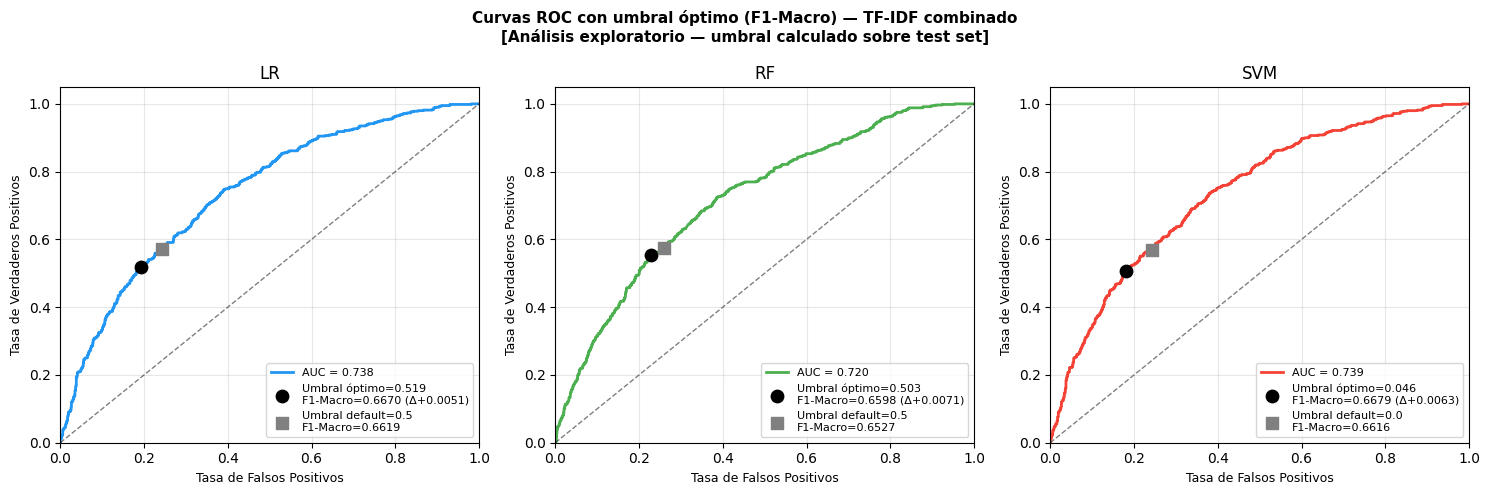


Guardado: roc_umbral_optimo.png


In [29]:
# ═══════════════════════════════════════════════════════════════
# CELDA — Análisis exploratorio: umbral óptimo por F1-Macro
# NOTA: el umbral se calcula sobre el test set oficial únicamente
# como análisis post-entrenamiento. No se usa para reoptimizar
# el modelo ni se reporta como resultado principal.
# ═══════════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
import joblib
from sklearn.metrics import f1_score, roc_curve, auc
import matplotlib.pyplot as plt

DATA_DIR   = '../data'
MODELS_DIR = '../data/modelos'
FEATURE_COLS = ['n_exc','n_int','n_may','n_emo','n_ris',
                'n_neg','n_elo','n_com','n_pun']

df_test = pd.read_csv(f'{DATA_DIR}/test_clean.csv')
TESTS = {
    'combinado': df_test,
    'mx': pd.read_csv(f'{DATA_DIR}/test_clean_mx.csv'),
    'es': pd.read_csv(f'{DATA_DIR}/test_clean_es.csv'),
    'cu': pd.read_csv(f'{DATA_DIR}/test_clean_cu.csv'),
}
def buscar_umbral_optimo(model, X_te, y_te, modelo_nombre, n_umbrales=300):
    """
    Busca el umbral que maximiza F1-Macro sobre el conjunto de test.
    Retorna umbral óptimo, F1-Macro con umbral óptimo y con umbral por defecto.
    """
    # Scores de decisión
    if modelo_nombre == 'SVM':
        scores = model.decision_function(X_te)
        umbral_default = 0.0   # LinearSVC clasifica con score >= 0
    else:
        scores = model.predict_proba(X_te)[:, 1]
        umbral_default = 0.5   # probabilidad >= 0.5

    # Barrido de umbrales
    umbrales = np.linspace(scores.min(), scores.max(), n_umbrales)
    mejor_f1, mejor_u = 0, umbral_default

    for u in umbrales:
        pred = (scores >= u).astype(int)
        f1 = f1_score(y_te, pred, average='macro', zero_division=0)
        if f1 > mejor_f1:
            mejor_f1, mejor_u = f1, u

    # F1-Macro con umbral por defecto
    pred_default = (scores >= umbral_default).astype(int)
    f1_default   = f1_score(y_te, pred_default, average='macro', zero_division=0)

    return {
        'umbral_default': round(umbral_default, 4),
        'f1_default':     round(f1_default, 4),
        'umbral_optimo':  round(mejor_u, 4),
        'f1_optimo':      round(mejor_f1, 4),
        'delta':          round(mejor_f1 - f1_default, 4)
    }

# ── Análisis sobre TF-IDF combinado ──────────────────────────────────────────
print('=== ANÁLISIS EXPLORATORIO: UMBRAL ÓPTIMO (F1-Macro) ===')
print('Dataset: combinado | Representación: TF-IDF')
print('Nota: calculado sobre test set — solo valor exploratorio.\n')

df_te = TESTS['combinado']
X_te  = df_te[['MESSAGE_CLEAN'] + FEATURE_COLS]
y_te  = df_te['IS_IRONIC'].values

print(f'{"Modelo":6} {"U. default":>12} {"F1 default":>12} '
      f'{"U. óptimo":>12} {"F1 óptimo":>12} {"Δ F1":>8}')
print('-' * 66)

resultados_umbral = {}
for modelo_nombre in ['LR', 'RF', 'SVM']:
    model  = joblib.load(f'{MODELS_DIR}/ml_tf-idf_{modelo_nombre.lower()}_combinado.pkl')
    res    = buscar_umbral_optimo(model, X_te, y_te, modelo_nombre)
    resultados_umbral[modelo_nombre] = res
    signo  = f'+{res["delta"]}' if res["delta"] >= 0 else str(res["delta"])
    print(f'{modelo_nombre:6} {res["umbral_default"]:>12} {res["f1_default"]:>12} '
          f'{res["umbral_optimo"]:>12} {res["f1_optimo"]:>12} {signo:>8}')

# ── Visualización: curva ROC + umbral óptimo marcado ─────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(
    'Curvas ROC con umbral óptimo (F1-Macro) — TF-IDF combinado\n'
    '[Análisis exploratorio — umbral calculado sobre test set]',
    fontsize=11, fontweight='bold'
)

for i, (modelo_nombre, color) in enumerate(
    [('LR', '#2196F3'), ('RF', '#4CAF50'), ('SVM', '#F44336')]
):
    ax    = axes[i]
    model = joblib.load(f'{MODELS_DIR}/ml_tf-idf_{modelo_nombre.lower()}_combinado.pkl')
    res   = resultados_umbral[modelo_nombre]

    if modelo_nombre == 'SVM':
        scores = model.decision_function(X_te)
    else:
        scores = model.predict_proba(X_te)[:, 1]

    fpr, tpr, thresholds = roc_curve(y_te, scores)
    roc_auc = auc(fpr, tpr)

    # Curva ROC
    ax.plot(fpr, tpr, color=color, lw=2,
            label=f'AUC = {roc_auc:.3f}')

    # Marcar umbral óptimo en la curva
    idx_opt = np.argmin(np.abs(thresholds - res['umbral_optimo']))
    ax.scatter(fpr[idx_opt], tpr[idx_opt],
               color='black', zorder=5, s=80,
               label=f'Umbral óptimo={res["umbral_optimo"]:.3f}\n'
                     f'F1-Macro={res["f1_optimo"]:.4f} '
                     f'(Δ{res["delta"]:+.4f})')

    # Marcar umbral por defecto
    idx_def = np.argmin(np.abs(thresholds - res['umbral_default']))
    ax.scatter(fpr[idx_def], tpr[idx_def],
               color='gray', marker='s', zorder=5, s=80,
               label=f'Umbral default={res["umbral_default"]}\n'
                     f'F1-Macro={res["f1_default"]:.4f}')

    ax.plot([0,1], [0,1], 'k--', lw=1, alpha=0.5)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.05])
    ax.set_xlabel('Tasa de Falsos Positivos', fontsize=9)
    ax.set_ylabel('Tasa de Verdaderos Positivos', fontsize=9)
    ax.set_title(modelo_nombre, fontsize=12)
    ax.legend(loc='lower right', fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{DATA_DIR}/roc_umbral_optimo.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nGuardado: roc_umbral_optimo.png')